In [1]:
import os
import glob
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne

from scipy.signal import welch
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# EEG configuration
DATASET_ROOT = r"C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148"

CHANNELS = ["Fp1", "Fp2", "Fz"]

EXPECTED_FS = 500

WINDOW_SECONDS = 4
WINDOW_SAMPLES = EXPECTED_FS * WINDOW_SECONDS

STEP_SECONDS = 4
STEP_SAMPLES = EXPECTED_FS * STEP_SECONDS

LOWCUT = 0.3
HIGHCUT = 45.0

ARTIFACT_PTP_UV = 100.0
MIN_CHANNEL_STD_UV = 0.1

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

print("Imports successful.")
print("MNE version:", mne.__version__)

Imports successful.
MNE version: 1.13.2


In [2]:
vhdr_files = sorted(
    glob.glob(
        os.path.join(
            DATASET_ROOT,
            "sub-*",
            "ses-*",
            "eeg",
            "*.vhdr"
        )
    )
)

print("Total EEG recordings found:", len(vhdr_files))

print("\nFirst 10 files:")
for f in vhdr_files[:10]:
    print(f)

Total EEG recordings found: 180

First 10 files:
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session1\eeg\sub-01_ses-session1_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session2\eeg\sub-01_ses-session2_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session3\eeg\sub-01_ses-session3_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-02\ses-session1\eeg\sub-02_ses-session1_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-02\ses-session2\eeg\sub-02_ses-session2_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-02\ses-session3\eeg\sub-02_ses-session3_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-03\ses-session1\eeg\sub-03_ses-session1_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-03\ses-session2\eeg\sub-03_ses-session2_task

In [3]:
records = []

for vhdr in vhdr_files:

    parts = os.path.normpath(vhdr).split(os.sep)

    subject = next(
        p for p in parts
        if p.startswith("sub-")
    )

    session = next(
        p for p in parts
        if p.startswith("ses-")
    )

    records.append({
        "subject": subject,
        "session": session,
        "vhdr": vhdr
    })

records_df = pd.DataFrame(records)

print(records_df.head())

print("\nSubjects:")
print(records_df["subject"].nunique())

print("\nSessions:")
print(records_df["session"].value_counts())

print("\nRecordings:")
print(len(records_df))

  subject       session                                               vhdr
0  sub-01  ses-session1  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...
1  sub-01  ses-session2  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...
2  sub-01  ses-session3  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...
3  sub-02  ses-session1  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...
4  sub-02  ses-session2  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...

Subjects:
60

Sessions:
session
ses-session1    60
ses-session2    60
ses-session3    60
Name: count, dtype: int64

Recordings:
180


In [4]:
test_file = vhdr_files[0]

print("Testing:")
print(test_file)

raw = mne.io.read_raw_brainvision(
    test_file,
    preload=True,
    verbose=False
)

print("\nSampling frequency:")
print(raw.info["sfreq"])

print("\nNumber of channels:")
print(len(raw.ch_names))

print("\nFirst channels:")
print(raw.ch_names[:20])

Testing:
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session1\eeg\sub-01_ses-session1_task-memory_eeg.vhdr

Sampling frequency:
500.0

Number of channels:
61

First channels:
['Fp1', 'AF3', 'AF7', 'Fz', 'F1', 'F3', 'F5', 'F7', 'FC1', 'FC3', 'FC5', 'FT7', 'Cz', 'C1', 'C3', 'C5', 'T7', 'CP1', 'CP3', 'CP5']


In [5]:
missing = [
    ch for ch in CHANNELS
    if ch not in raw.ch_names
]

if missing:
    raise ValueError(
        f"Missing channels: {missing}"
    )

raw_3ch = raw.copy().pick(CHANNELS)

print(raw_3ch)
print("\nSelected channels:")
print(raw_3ch.ch_names)

print("\nSampling rate:")
print(raw_3ch.info["sfreq"])

<RawBrainVision | sub-01_ses-session1_task-memory_eeg.eeg, 3 x 150000 (300.0 s), ~3.4 MiB, data loaded>

Selected channels:
['Fp1', 'Fp2', 'Fz']

Sampling rate:
500.0


In [6]:
def preprocess_recording(vhdr_path):

    raw = mne.io.read_raw_brainvision(
        vhdr_path,
        preload=True,
        verbose=False
    )

    # ------------------------------------------------
    # Check sampling frequency
    # ------------------------------------------------

    fs = raw.info["sfreq"]

    if abs(fs - EXPECTED_FS) > 1e-6:
        raise ValueError(
            f"Expected {EXPECTED_FS} Hz but found {fs} Hz:\n"
            f"{vhdr_path}"
        )

    # ------------------------------------------------
    # Select channels
    # ------------------------------------------------

    missing = [
        ch for ch in CHANNELS
        if ch not in raw.ch_names
    ]

    if missing:
        raise ValueError(
            f"Missing channels {missing} in {vhdr_path}"
        )

    raw.pick(CHANNELS)

    # ------------------------------------------------
    # Bandpass filter
    # ------------------------------------------------

    raw.filter(
        l_freq=LOWCUT,
        h_freq=HIGHCUT,
        method="fir",
        phase="zero",
        verbose=False
    )

    # ------------------------------------------------
    # Get data
    # ------------------------------------------------

    data = raw.get_data()

    # Convert V → µV
    data_uv = data * 1e6

    # ------------------------------------------------
    # Windowing
    # ------------------------------------------------

    n_samples = data_uv.shape[1]

    windows = []
    rejected = 0

    for start in range(
        0,
        n_samples - WINDOW_SAMPLES + 1,
        STEP_SAMPLES
    ):

        end = start + WINDOW_SAMPLES

        window = data_uv[:, start:end]

        # --------------------------------------------
        # NaN / Inf
        # --------------------------------------------

        if not np.isfinite(window).all():
            rejected += 1
            continue

        # --------------------------------------------
        # Frontal artifact rejection
        # --------------------------------------------

        fp1_ptp = np.ptp(window[0])
        fp2_ptp = np.ptp(window[1])

        if (
            fp1_ptp > ARTIFACT_PTP_UV
            or
            fp2_ptp > ARTIFACT_PTP_UV
        ):
            rejected += 1
            continue

        # --------------------------------------------
        # Flatline rejection
        # --------------------------------------------

        channel_std = np.std(
            window,
            axis=1
        )

        if np.any(
            channel_std < MIN_CHANNEL_STD_UV
        ):
            rejected += 1
            continue

        windows.append(window)

    if len(windows) == 0:
        return np.empty(
            (0, 3, WINDOW_SAMPLES),
            dtype=np.float32
        ), rejected

    windows = np.asarray(
        windows,
        dtype=np.float32
    )

    return windows, rejected

In [7]:
windows, rejected = preprocess_recording(
    vhdr_files[0]
)

print("Windows:", windows.shape)
print("Rejected:", rejected)

if len(windows) > 0:

    print("\nWindow shape:")
    print(windows[0].shape)

    print("\nExpected:")
    print("(3, 2000)")

Windows: (69, 3, 2000)
Rejected: 6

Window shape:
(3, 2000)

Expected:
(3, 2000)


In [8]:
all_windows = []
metadata = []

total_rejected = 0

start_time = time.time()

for _, row in tqdm(
    records_df.iterrows(),
    total=len(records_df),
    desc="Preprocessing EEG"
):

    subject = row["subject"]
    session = row["session"]
    vhdr = row["vhdr"]

    try:

        windows, rejected = preprocess_recording(
            vhdr
        )

    except Exception as e:

        print("\nERROR:")
        print(vhdr)
        print(e)
        continue

    total_rejected += rejected

    for i, window in enumerate(windows):

        all_windows.append(window)

        metadata.append({
            "subject": subject,
            "session": session,
            "window": i
        })

X_raw = np.asarray(
    all_windows,
    dtype=np.float32
)

metadata_df = pd.DataFrame(
    metadata
)

print("\n==============================")
print("PREPROCESSING COMPLETE")
print("==============================")

print("X shape:", X_raw.shape)

print(
    "Total accepted windows:",
    len(X_raw)
)

print(
    "Total rejected windows:",
    total_rejected
)

print(
    "Time:",
    round((time.time() - start_time) / 60, 2),
    "minutes"
)

Preprocessing EEG:   0%|          | 0/180 [00:00<?, ?it/s]


PREPROCESSING COMPLETE
X shape: (8735, 3, 2000)
Total accepted windows: 8735
Total rejected windows: 4761
Time: 0.6 minutes


In [9]:
PROCESSED_DIR = os.path.join(
    DATASET_ROOT,
    "processed"
)

os.makedirs(
    PROCESSED_DIR,
    exist_ok=True
)

np.save(
    os.path.join(
        PROCESSED_DIR,
        "X_raw.npy"
    ),
    X_raw
)

metadata_df.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "metadata.csv"
    ),
    index=False
)

print("Saved preprocessing results.")

Saved preprocessing results.


In [10]:
def hjorth_parameters(signal):

    activity = np.var(signal)

    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var_diff1 = np.var(diff1)
    var_diff2 = np.var(diff2)

    if activity <= 1e-12:
        mobility = 0.0
    else:
        mobility = np.sqrt(
            var_diff1 / activity
        )

    if var_diff1 <= 1e-12:
        complexity = 0.0
    else:
        mobility_diff = np.sqrt(
            var_diff2 / var_diff1
        )

        complexity = (
            mobility_diff / mobility
            if mobility > 1e-12
            else 0.0
        )

    return activity, mobility, complexity

In [11]:
def extract_features(window, fs=500):

    features = []
    names = []

    for ch_idx, ch_name in enumerate(CHANNELS):

        signal = window[ch_idx]

        # ------------------------------------------
        # Time-domain
        # ------------------------------------------

        mean_val = np.mean(signal)
        std_val = np.std(signal)
        rms_val = np.sqrt(
            np.mean(signal ** 2)
        )

        skew_val = skew(signal)
        kurt_val = kurtosis(signal)

        activity, mobility, complexity = (
            hjorth_parameters(signal)
        )

        time_features = {
            "mean": mean_val,
            "std": std_val,
            "rms": rms_val,
            "skew": skew_val,
            "kurtosis": kurt_val,
            "hjorth_activity": activity,
            "hjorth_mobility": mobility,
            "hjorth_complexity": complexity
        }

        for name, value in time_features.items():

            names.append(
                f"{ch_name}_{name}"
            )

            features.append(value)

        # ------------------------------------------
        # Welch PSD
        # ------------------------------------------

        freqs, psd = welch(
            signal,
            fs=fs,
            nperseg=min(
                512,
                len(signal)
            ),
            noverlap=None
        )

        # 1–45 Hz
        valid = (
            (freqs >= 1)
            &
            (freqs <= 45)
        )

        freqs_valid = freqs[valid]
        psd_valid = psd[valid]

        total_power = np.trapezoid(
            psd_valid,
            freqs_valid
        )

        # ------------------------------------------
        # Band powers
        # ------------------------------------------

        band_powers = {}

        for band_name, (low, high) in BANDS.items():

            mask = (
                (freqs >= low)
                &
                (freqs < high)
            )

            if np.any(mask):

                power = np.trapezoid(
                    psd[mask],
                    freqs[mask]
                )

            else:

                power = 0.0

            band_powers[band_name] = power

            features.append(
                power
            )

            names.append(
                f"{ch_name}_{band_name}_power"
            )

        # ------------------------------------------
        # Relative bandpower
        # ------------------------------------------

        for band_name in BANDS:

            rel = (
                band_powers[band_name]
                / (total_power + 1e-12)
            )

            features.append(rel)

            names.append(
                f"{ch_name}_{band_name}_relative"
            )

        # ------------------------------------------
        # Log PSD bins
        # ------------------------------------------

        log_psd = np.log10(
            psd_valid + 1e-12
        )

        # 20 evenly distributed PSD features
        psd_bins = np.array_split(
            log_psd,
            20
        )

        for i, b in enumerate(psd_bins):

            value = np.mean(b)

            features.append(value)

            names.append(
                f"{ch_name}_logPSD_bin_{i}"
            )

    return (
        np.asarray(features, dtype=np.float32),
        names
    )

In [12]:
feature_rows = []

feature_names = None

start_time = time.time()

for window in tqdm(
    X_raw,
    desc="Extracting EEG features"
):

    features, names = extract_features(
        window,
        fs=EXPECTED_FS
    )

    feature_rows.append(features)

    if feature_names is None:
        feature_names = names

X_features = np.asarray(
    feature_rows,
    dtype=np.float32
)

features_df = pd.DataFrame(
    X_features,
    columns=feature_names
)

print("\nFeature matrix:")
print(features_df.shape)

print("\nFirst features:")
print(features_df.columns[:20].tolist())

print(
    "\nFeature extraction time:",
    round((time.time() - start_time) / 60, 2),
    "minutes"
)

Extracting EEG features:   0%|          | 0/8735 [00:00<?, ?it/s]


Feature matrix:
(8735, 114)

First features:
['Fp1_mean', 'Fp1_std', 'Fp1_rms', 'Fp1_skew', 'Fp1_kurtosis', 'Fp1_hjorth_activity', 'Fp1_hjorth_mobility', 'Fp1_hjorth_complexity', 'Fp1_delta_power', 'Fp1_theta_power', 'Fp1_alpha_power', 'Fp1_beta_power', 'Fp1_gamma_power', 'Fp1_delta_relative', 'Fp1_theta_relative', 'Fp1_alpha_relative', 'Fp1_beta_relative', 'Fp1_gamma_relative', 'Fp1_logPSD_bin_0', 'Fp1_logPSD_bin_1']

Feature extraction time: 1.42 minutes


In [13]:
FEATURE_DIR = os.path.join(
    DATASET_ROOT,
    "features"
)

os.makedirs(
    FEATURE_DIR,
    exist_ok=True
)

features_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "eeg_features.csv"
    ),
    index=False
)

metadata_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "metadata.csv"
    ),
    index=False
)

print("Feature dataset saved.")

Feature dataset saved.


In [14]:
features_df = pd.read_csv(
    os.path.join(
        FEATURE_DIR,
        "eeg_features.csv"
    )
)

metadata_df = pd.read_csv(
    os.path.join(
        FEATURE_DIR,
        "metadata.csv"
    )
)

X_features = features_df.values.astype(
    np.float32
)

print("Features:", X_features.shape)
print("Metadata:", metadata_df.shape)

Features: (8735, 114)
Metadata: (8735, 3)


In [15]:
subjects = sorted(
    metadata_df["subject"].unique()
)

subject_to_id = {
    s: i
    for i, s in enumerate(subjects)
}

metadata_df["subject_id"] = (
    metadata_df["subject"]
    .map(subject_to_id)
)

print("Number of subjects:", len(subjects))

print(
    metadata_df[
        ["subject", "subject_id"]
    ].drop_duplicates().head()
)

Number of subjects: 60
    subject  subject_id
0    sub-01           0
198  sub-02           1
273  sub-03           2
343  sub-04           3
520  sub-05           4


In [ ]:

# EEG AUTHENTICATION
# 60 INDEPENDENT BINARY SVM VERIFIERS
#
# Enrollment:
#   Session 1 + Session 2
#
# Authentication:
#   Session 3
#
# Each SVM:
#   Target subject     = +1
#   All other subjects = -1


subjects = sorted(
    metadata_df["subject"].unique()
)

print("=" * 80)
print("SUBJECT INFORMATION")
print("=" * 80)

print("Number of subjects:", len(subjects))

if len(subjects) != 60:
    raise ValueError(
        f"Expected 60 subjects but found {len(subjects)}"
    )

subject_to_id = {
    subject: idx
    for idx, subject in enumerate(subjects)
}

metadata_df["subject_id"] = (
    metadata_df["subject"]
    .map(subject_to_id)
)

print("\nSubject mapping:")
print(
    metadata_df[
        ["subject", "subject_id"]
    ]
    .drop_duplicates()
    .head(10)
)

print("\nSession counts:")
print(
    metadata_df["session"]
    .value_counts()
    .sort_index()
)

SUBJECT INFORMATION
Number of subjects: 60

Subject mapping:
     subject  subject_id
0     sub-01           0
198   sub-02           1
273   sub-03           2
343   sub-04           3
520   sub-05           4
623   sub-06           5
830   sub-07           6
1042  sub-08           7
1231  sub-09           8
1407  sub-10           9

Session counts:
session
ses-session1    3060
ses-session2    3040
ses-session3    2635
Name: count, dtype: int64


In [ ]:

ENROLLMENT_SESSIONS = [
    "ses-session1",
    "ses-session2"
]

TEST_SESSION = "ses-session3"

# Number of consecutive EEG windows
# used to form one authentication attempt.
#
# K=1  -> 4 seconds
# K=3  -> 12 seconds
# K=5  -> 20 seconds
# K=10 -> 40 seconds

K_LIST = [1, 3, 5, 10]

# SVM parameters
SVM_C = 10
SVM_KERNEL = "rbf"
SVM_GAMMA = "scale"

# PCA
PCA_VARIANCE = 0.99

print("=" * 80)
print("EXPERIMENT CONFIGURATION")
print("=" * 80)

print("Enrollment:", ENROLLMENT_SESSIONS)
print("Authentication:", TEST_SESSION)
print("K values:", K_LIST)
print("SVM:", SVM_KERNEL)
print("C:", SVM_C)
print("PCA variance:", PCA_VARIANCE)

EXPERIMENT CONFIGURATION
Enrollment: ['ses-session1', 'ses-session2']
Authentication: ses-session3
K values: [1, 3, 5, 10]
SVM: rbf
C: 10
PCA variance: 0.99


In [ ]:
enrollment_mask = (
    metadata_df["session"]
    .isin(ENROLLMENT_SESSIONS)
)

X_enrollment = X_features[
    enrollment_mask
]

metadata_enrollment = metadata_df.loc[
    enrollment_mask
].copy()

y_enrollment = (
    metadata_enrollment["subject_id"]
    .values
)

print("=" * 80)
print("ENROLLMENT DATA")
print("=" * 80)

print("Enrollment samples:", len(X_enrollment))
print("Feature dimension:", X_enrollment.shape[1])

print("\nSamples per subject:")

print(
    metadata_enrollment
    .groupby("subject")["subject_id"]
    .count()
    .describe()
)

ENROLLMENT DATA
Enrollment samples: 6100
Feature dimension: 114

Samples per subject:
count     60.000000
mean     101.666667
std       40.341620
min        3.000000
25%       77.750000
50%      116.500000
75%      136.250000
max      148.000000
Name: subject_id, dtype: float64


In [ ]:
test_mask = (
    metadata_df["session"]
    == TEST_SESSION
)

X_test = X_features[
    test_mask
]

metadata_test = metadata_df.loc[
    test_mask
].copy()

y_test = (
    metadata_test["subject_id"]
    .values
)

print("=" * 80)
print("AUTHENTICATION DATA")
print("=" * 80)

print("Authentication samples:", len(X_test))
print("Feature dimension:", X_test.shape[1])

print("\nSamples per subject:")

print(
    metadata_test
    .groupby("subject")["subject_id"]
    .count()
    .describe()
)

AUTHENTICATION DATA
Authentication samples: 2635
Feature dimension: 114

Samples per subject:
count    57.000000
mean     46.228070
std      19.177756
min       1.000000
25%      35.000000
50%      47.000000
75%      62.000000
max      73.000000
Name: subject_id, dtype: float64


In [ ]:
def train_subject_svm(
    target_subject_id,
    X_train,
    y_train
):

    # Binary labels
    # Target subject     -> +1
    # Everyone else      -> -1

    y_binary = np.where(
        y_train == target_subject_id,
        1,
        -1
    )

    positive_count = np.sum(
        y_binary == 1
    )

    negative_count = np.sum(
        y_binary == -1
    )

    if positive_count == 0:
        raise ValueError(
            f"No positive samples for subject "
            f"{target_subject_id}"
        )

    if negative_count == 0:
        raise ValueError(
            f"No negative samples for subject "
            f"{target_subject_id}"
        )

    # Standardization

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X_train
    )

    # PCA

    pca = PCA(
        n_components=PCA_VARIANCE,
        svd_solver="full",
        random_state=SEED
    )

    X_pca = pca.fit_transform(
        X_scaled
    )

    # --------------------------------------------------------
    # Binary SVM
    # --------------------------------------------------------

    svm = SVC(
        kernel=SVM_KERNEL,
        C=SVM_C,
        gamma=SVM_GAMMA,

        # 1 genuine class vs 59 impostor classes.
        
        class_weight="balanced",

        probability=False,
        random_state=SEED
    )

    svm.fit(
        X_pca,
        y_binary
    )

    return {
        "subject_id": target_subject_id,
        "scaler": scaler,
        "pca": pca,
        "svm": svm,
        "n_positive": positive_count,
        "n_negative": negative_count,
        "n_pca_components": X_pca.shape[1]
    }

In [ ]:
print("=" * 80)
print("TRAINING 60 SUBJECT-SPECIFIC SVMs")
print("=" * 80)

models = {}

training_start = time.time()

for subject_id in tqdm(
    range(len(subjects)),
    desc="Training SVMs"
):

    model_bundle = train_subject_svm(
        target_subject_id=subject_id,
        X_train=X_enrollment,
        y_train=y_enrollment
    )

    models[subject_id] = model_bundle


training_time = (
    time.time() - training_start
)

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Total models trained: {len(models)}"
)

print(
    f"Training time: "
    f"{training_time / 60:.2f} minutes"
)

print("\nExample model:")

example_model = models[0]

print(
    "Target subject:",
    subjects[
        example_model["subject_id"]
    ]
)

print(
    "Positive samples:",
    example_model["n_positive"]
)

print(
    "Negative samples:",
    example_model["n_negative"]
)

print(
    "PCA components:",
    example_model["n_pca_components"]
)

TRAINING 60 SUBJECT-SPECIFIC SVMs


Training SVMs:   0%|          | 0/60 [00:00<?, ?it/s]


TRAINING COMPLETE
Total models trained: 60
Training time: 0.20 minutes

Example model:
Target subject: sub-01
Positive samples: 142
Negative samples: 5958
PCA components: 83


Delete Existing Result 

In [22]:
""" # RESET RESULTS COMPLETELY

all_results = []
result_objects = {}

print("Results reset.") """

' # RESET RESULTS COMPLETELY\n\nall_results = []\nresult_objects = {}\n\nprint("Results reset.") '

In [ ]:
print("=" * 80)
print("MODEL VERIFICATION")
print("=" * 80)

print(
    "Total independent models:",
    len(models)
)

for subject_id in range(
    min(5, len(subjects))
):

    model_bundle = models[
        subject_id
    ]

    print(
        f"{subjects[subject_id]} -> "
        f"SVM target = "
        f"{subjects[model_bundle['subject_id']]}"
    )

MODEL VERIFICATION
Total independent models: 60
sub-01 -> SVM target = sub-01
sub-02 -> SVM target = sub-02
sub-03 -> SVM target = sub-03
sub-04 -> SVM target = sub-04
sub-05 -> SVM target = sub-05


In [ ]:
def create_attempts(
    scores,
    K
):

    n_attempts = (
        len(scores) // K
    )

    if n_attempts == 0:
        return np.array([])

    trimmed = scores[
        :n_attempts * K
    ]

    attempts = trimmed.reshape(
        n_attempts,
        K
    ).mean(axis=1)

    return attempts

In [ ]:
def collect_authentication_scores(
    models,
    X_test,
    y_test,
    K
):

    genuine_scores = []
    impostor_scores = []

    subject_results = {}

    for target_subject_id in tqdm(
        range(len(subjects)),
        desc=f"Evaluating K={K}"
    ):

        model_bundle = models[
            target_subject_id
        ]

        scaler = model_bundle[
            "scaler"
        ]

        pca = model_bundle[
            "pca"
        ]

        svm = model_bundle[
            "svm"
        ]

        # Transform Session 3

        X_test_scaled = scaler.transform(
            X_test
        )

        X_test_pca = pca.transform(
            X_test_scaled
        )

        # SVM decision scores


        all_scores = svm.decision_function(
            X_test_pca
        )

        # Target subject = GENUINE

        genuine_mask = (
            y_test == target_subject_id
        )

        genuine_window_scores = (
            all_scores[
                genuine_mask
            ]
        )

        genuine_attempt_scores = (
            create_attempts(
                genuine_window_scores,
                K
            )
        )


        impostor_attempt_scores = []

        for impostor_subject_id in range(
            len(subjects)
        ):

            if (
                impostor_subject_id
                == target_subject_id
            ):
                continue

            impostor_mask = (
                y_test
                == impostor_subject_id
            )

            subject_impostor_scores = (
                all_scores[
                    impostor_mask
                ]
            )

            attempts = create_attempts(
                subject_impostor_scores,
                K
            )

            if len(attempts) > 0:

                impostor_attempt_scores.extend(
                    attempts.tolist()
                )

        impostor_attempt_scores = np.asarray(
            impostor_attempt_scores,
            dtype=np.float64
        )


        if len(genuine_attempt_scores) > 0:

            genuine_scores.extend(
                genuine_attempt_scores.tolist()
            )

        if len(impostor_attempt_scores) > 0:

            impostor_scores.extend(
                impostor_attempt_scores.tolist()
            )

        subject_results[
            target_subject_id
        ] = {
            "genuine_scores":
                genuine_attempt_scores,

            "impostor_scores":
                impostor_attempt_scores
        }

    genuine_scores = np.asarray(
        genuine_scores,
        dtype=np.float64
    )

    impostor_scores = np.asarray(
        impostor_scores,
        dtype=np.float64
    )

    return (
        genuine_scores,
        impostor_scores,
        subject_results
    )

In [ ]:
def calculate_eer(
    genuine_scores,
    impostor_scores
):

    if len(genuine_scores) == 0:
        raise ValueError(
            "No genuine scores available."
        )

    if len(impostor_scores) == 0:
        raise ValueError(
            "No impostor scores available."
        )

    # Genuine  = 1
    # Impostor = 0

    y_true = np.concatenate([
        np.ones(
            len(genuine_scores)
        ),

        np.zeros(
            len(impostor_scores)
        )
    ])

    # Scores

    y_score = np.concatenate([
        genuine_scores,
        impostor_scores
    ])

  
    # ROC
 

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score
    )

    # FRR

    fnr = 1.0 - tpr

    # EER


    eer_index = np.nanargmin(
        np.abs(
            fpr - fnr
        )
    )

    far_at_eer = fpr[
        eer_index
    ]

    frr_at_eer = fnr[
        eer_index
    ]

    eer = (
        far_at_eer
        + frr_at_eer
    ) / 2.0

    eer_threshold = thresholds[
        eer_index
    ]

    tar_at_eer = tpr[
        eer_index
    ]

    # ROC AUC

    auc = roc_auc_score(
        y_true,
        y_score
    )

    return {
        "EER": eer,
        "EER_%": eer * 100,

        "threshold":
            eer_threshold,

        "FAR":
            far_at_eer,

        "FAR_%":
            far_at_eer * 100,

        "FRR":
            frr_at_eer,

        "FRR_%":
            frr_at_eer * 100,

        "TAR":
            tar_at_eer,

        "TAR_%":
            tar_at_eer * 100,

        "ROC_AUC":
            auc,

        "fpr":
            fpr,

        "tpr":
            tpr,

        "fnr":
            fnr,

        "thresholds":
            thresholds
    }

In [ ]:
print("=" * 80)
print("SESSION 3 AUTHENTICATION EXPERIMENT")
print("=" * 80)

print("\nEnrollment:")
print("  Session 1 + Session 2")

print("\nAuthentication:")
print("  Session 3")

print("\nNumber of subjects:")
print(len(subjects))

print("\nK values:")
print(K_LIST)

print("\n" + "=" * 80)


all_results = []

result_objects = {}

experiment_start = time.time()


for K in K_LIST:

    print("\n")
    print("=" * 80)
    print(f"K = {K}")
    print(
        f"Authentication duration = "
        f"{K * WINDOW_SECONDS} seconds"
    )
    print("=" * 80)

    # Generate scores
 
    (
        genuine_scores,
        impostor_scores,
        subject_results
    ) = collect_authentication_scores(
        models=models,
        X_test=X_test,
        y_test=y_test,
        K=K
    )

    print(
        "\nGenuine attempts:",
        len(genuine_scores)
    )

    print(
        "Impostor attempts:",
        len(impostor_scores)
    )

    # Calculate metrics
 

    metrics = calculate_eer(
        genuine_scores,
        impostor_scores
    )

    # Store complete result
   
    result = {
        "protocol":
            "S1+S2 -> S3",

        "K":
            K,

        "attempt_seconds":
            K * WINDOW_SECONDS,

        "n_subjects":
            len(subjects),

        "n_genuine":
            len(genuine_scores),

        "n_impostor":
            len(impostor_scores),

        "EER":
            metrics["EER"],

        "EER_%":
            metrics["EER_%"],

        "threshold":
            metrics["threshold"],

        "FAR":
            metrics["FAR"],

        "FAR_%":
            metrics["FAR_%"],

        "FRR":
            metrics["FRR"],

        "FRR_%":
            metrics["FRR_%"],

        "TAR":
            metrics["TAR"],

        "TAR_%":
            metrics["TAR_%"],

        "ROC_AUC":
            metrics["ROC_AUC"],

        "genuine_scores":
            genuine_scores,

        "impostor_scores":
            impostor_scores,

        "fpr":
            metrics["fpr"],

        "tpr":
            metrics["tpr"],

        "fnr":
            metrics["fnr"],

        "thresholds":
            metrics["thresholds"],

        "subject_results":
            subject_results
    }

    result_objects[
        K
    ] = result

    # Flat result for DataFrame
   

    all_results.append({

        "protocol":
            "S1+S2 -> S3",

        "K":
            K,

        "attempt_seconds":
            K * WINDOW_SECONDS,

        "n_subjects":
            len(subjects),

        "n_genuine":
            len(genuine_scores),

        "n_impostor":
            len(impostor_scores),

        "EER":
            metrics["EER"],

        "EER_%":
            metrics["EER_%"],

        "threshold":
            metrics["threshold"],

        "FAR":
            metrics["FAR"],

        "FAR_%":
            metrics["FAR_%"],

        "FRR":
            metrics["FRR"],

        "FRR_%":
            metrics["FRR_%"],

        "TAR":
            metrics["TAR"],

        "TAR_%":
            metrics["TAR_%"],

        "ROC_AUC":
            metrics["ROC_AUC"]
    })

    print("\nRESULT")

    print(
        f"EER       : "
        f"{metrics['EER_%']:.2f}%"
    )

    print(
        f"FAR       : "
        f"{metrics['FAR_%']:.2f}%"
    )

    print(
        f"FRR       : "
        f"{metrics['FRR_%']:.2f}%"
    )

    print(
        f"TAR       : "
        f"{metrics['TAR_%']:.2f}%"
    )

    print(
        f"ROC-AUC   : "
        f"{metrics['ROC_AUC']:.4f}"
    )

    print(
        f"Threshold : "
        f"{metrics['threshold']:.6f}"
    )


experiment_time = (
    time.time()
    - experiment_start
)

print("\n")
print("=" * 80)
print("EXPERIMENT COMPLETE")
print("=" * 80)

print(
    f"Total evaluation time: "
    f"{experiment_time / 60:.2f} minutes"
)

SESSION 3 AUTHENTICATION EXPERIMENT

Enrollment:
  Session 1 + Session 2

Authentication:
  Session 3

Number of subjects:
60

K values:
[1, 3, 5, 10]



K = 1
Authentication duration = 4 seconds


Evaluating K=1:   0%|          | 0/60 [00:00<?, ?it/s]


Genuine attempts: 2635
Impostor attempts: 155465

RESULT
EER       : 23.72%
FAR       : 23.72%
FRR       : 23.72%
TAR       : 76.28%
ROC-AUC   : 0.8354
Threshold : -1.607477


K = 3
Authentication duration = 12 seconds


Evaluating K=3:   0%|          | 0/60 [00:00<?, ?it/s]


Genuine attempts: 859
Impostor attempts: 50681

RESULT
EER       : 20.46%
FAR       : 20.43%
FRR       : 20.49%
TAR       : 79.51%
ROC-AUC   : 0.8708
Threshold : -1.592019


K = 5
Authentication duration = 20 seconds


Evaluating K=5:   0%|          | 0/60 [00:00<?, ?it/s]


Genuine attempts: 506
Impostor attempts: 29854

RESULT
EER       : 18.76%
FAR       : 18.74%
FRR       : 18.77%
TAR       : 81.23%
ROC-AUC   : 0.8802
Threshold : -1.573047


K = 10
Authentication duration = 40 seconds


Evaluating K=10:   0%|          | 0/60 [00:00<?, ?it/s]


Genuine attempts: 241
Impostor attempts: 14219

RESULT
EER       : 17.04%
FAR       : 17.07%
FRR       : 17.01%
TAR       : 82.99%
ROC-AUC   : 0.8924
Threshold : -1.558109


EXPERIMENT COMPLETE
Total evaluation time: 0.31 minutes


In [ ]:

results_df = pd.DataFrame(
    all_results
)

display(
    results_df[
        [
            "protocol",
            "K",
            "attempt_seconds",
            "n_subjects",
            "n_genuine",
            "n_impostor",
            "EER_%",
            "FAR_%",
            "FRR_%",
            "TAR_%",
            "ROC_AUC"
        ]
    ]
)

,protocol,K,attempt_seconds,n_subjects,n_genuine,n_impostor,EER_%,FAR_%,FRR_%,TAR_%,ROC_AUC
0,S1+S2 -> S3,1,4,60,2635,155465,23.717557,23.715949,23.719165,76.280835,0.835449
1,S1+S2 -> S3,3,12,60,859,50681,20.460330,20.431720,20.488941,79.511059,0.870849
2,S1+S2 -> S3,5,20,60,506,29854,18.756281,18.737858,18.774704,81.225296,0.880208
3,S1+S2 -> S3,10,40,60,241,14219,17.040580,17.068711,17.012448,82.987552,0.892363


Accuracy With 4 Sec Windwing 

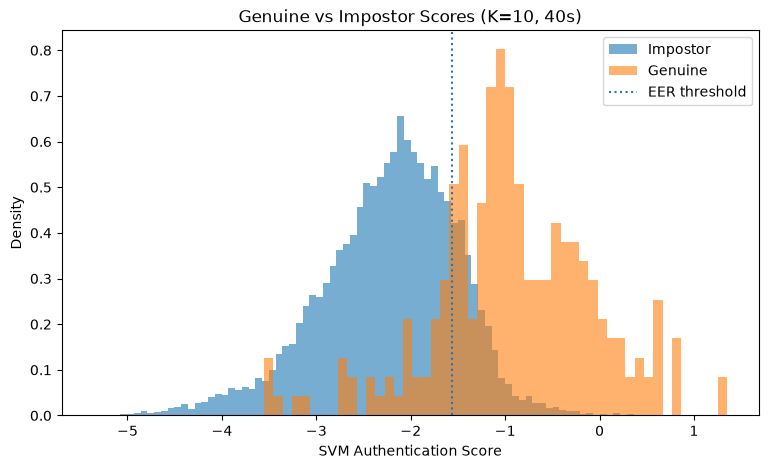

In [ ]:


K = 10

r = result_objects[K]

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    r["impostor_scores"],
    bins=80,
    alpha=0.6,
    density=True,
    label="Impostor"
)

plt.hist(
    r["genuine_scores"],
    bins=50,
    alpha=0.6,
    density=True,
    label="Genuine"
)

plt.axvline(
    r["threshold"],
    linestyle=":",
    label="EER threshold"
)

plt.xlabel(
    "SVM Authentication Score"
)

plt.ylabel(
    "Density"
)

plt.title(
    f"Genuine vs Impostor Scores "
    f"(K={K}, {K * WINDOW_SECONDS}s)"
)

plt.legend()

plt.show()

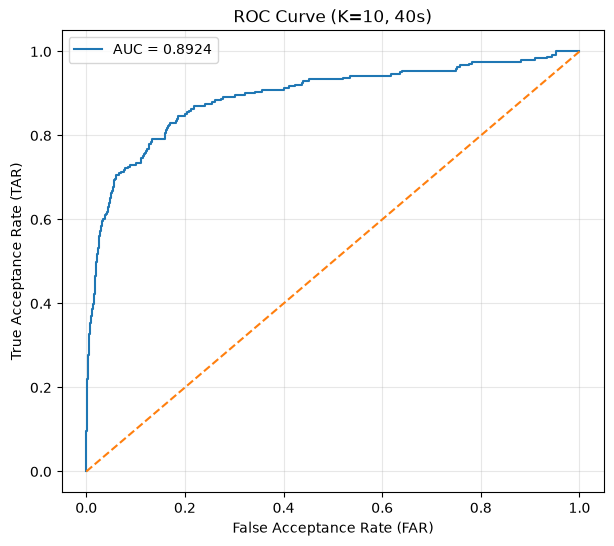

In [ ]:
 

K = 10

r = result_objects[K]

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    r["fpr"],
    r["tpr"],
    label=(
        f"AUC = "
        f"{r['ROC_AUC']:.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Acceptance Rate (FAR)"
)

plt.ylabel(
    "True Acceptance Rate (TAR)"
)

plt.title(
    f"ROC Curve "
    f"(K={K}, {K * WINDOW_SECONDS}s)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

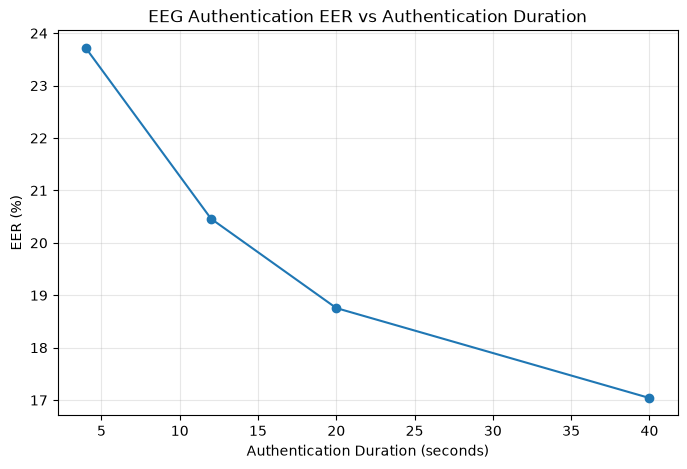

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    results_df["attempt_seconds"],
    results_df["EER_%"],
    marker="o"
)

plt.xlabel(
    "Authentication Duration (seconds)"
)

plt.ylabel(
    "EER (%)"
)

plt.title(
    "EEG Authentication EER vs Authentication Duration"
)

plt.grid(
    alpha=0.3
)

plt.show()

In [ ]:
def calculate_subject_eer(
    genuine_scores,
    impostor_scores
):

    if (
        len(genuine_scores) == 0
        or
        len(impostor_scores) == 0
    ):
        return np.nan

    y_true = np.concatenate([
        np.ones(
            len(genuine_scores)
        ),
        np.zeros(
            len(impostor_scores)
        )
    ])

    y_score = np.concatenate([
        genuine_scores,
        impostor_scores
    ])

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score
    )

    fnr = 1 - tpr

    idx = np.nanargmin(
        np.abs(
            fpr - fnr
        )
    )

    eer = (
        fpr[idx]
        + fnr[idx]
    ) / 2

    return eer


K = 10

subject_results = (
    result_objects[K]["subject_results"]
)

subject_metrics = []


for subject_id in range(
    len(subjects)
):

    data = subject_results[
        subject_id
    ]

    genuine = data[
        "genuine_scores"
    ]

    impostor = data[
        "impostor_scores"
    ]

    eer = calculate_subject_eer(
        genuine,
        impostor
    )

    subject_metrics.append({

        "subject_id":
            subject_id,

        "subject":
            subjects[subject_id],

        "n_genuine":
            len(genuine),

        "n_impostor":
            len(impostor),

        "EER_%":
            eer * 100
            if not np.isnan(eer)
            else np.nan
    })


subject_metrics_df = pd.DataFrame(
    subject_metrics
)

display(
    subject_metrics_df
)

,subject_id,subject,n_genuine,n_impostor,EER_%
0,0,sub-01,5,236,38.008475
1,1,sub-02,0,241,NaN
2,2,sub-03,4,237,4.430380
3,3,sub-04,5,236,15.932203
4,4,sub-05,4,237,0.000000
5,5,sub-06,7,234,0.854701
6,6,sub-07,7,234,2.564103
7,7,sub-08,5,236,2.542373
8,8,sub-09,5,236,1.271186
9,9,sub-10,7,234,0.000000


In [ ]:
print("=" * 80)
print("SUBJECT-LEVEL EER STATISTICS")
print("=" * 80)

print(
    "Mean EER:",
    subject_metrics_df["EER_%"].mean()
)

print(
    "Median EER:",
    subject_metrics_df["EER_%"].median()
)

print(
    "Best EER:",
    subject_metrics_df["EER_%"].min()
)

print(
    "Worst EER:",
    subject_metrics_df["EER_%"].max()
)

print(
    "Std EER:",
    subject_metrics_df["EER_%"].std()
)

SUBJECT-LEVEL EER STATISTICS
Mean EER: 11.594716945026706
Median EER: 2.75884453099643
Best EER: 0.0
Worst EER: 71.99152542372882
Std EER: 17.406751752788818


In [ ]:
RESULTS_DIR = os.path.join(
    DATASET_ROOT,
    "results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# Overall results


results_path = os.path.join(
    RESULTS_DIR,
    "binary_svm_authentication_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)


# Subject-level results

subject_results_path = os.path.join(
    RESULTS_DIR,
    "binary_svm_subject_level_results.csv"
)

subject_metrics_df.to_csv(
    subject_results_path,
    index=False
)


print("=" * 80)
print("RESULTS SAVED")
print("=" * 80)

print(
    "Overall:",
    results_path
)

print(
    "Subject-level:",
    subject_results_path
)

RESULTS SAVED
Overall: C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\results\binary_svm_authentication_results.csv
Subject-level: C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\results\binary_svm_subject_level_results.csv
